# Credit Card Fraud Detection
## 1. Overview
In this project, I used a real-world credit card transaction dataset that includes a mix of legitimate and fraudulent transactions. Each transaction is described using various anonymized features (to protect privacy), as well as a label indicating whether it was fraudulent. The main steps I took:
- Data Cleaning & Exploration: I explored the distribution of fraudulent vs. non-fraudulent transactions and handled the highly imbalanced nature of the data (since fraud cases are rare).
- Feature Engineering: I analyzed time-based patterns and transaction behaviors to extract meaningful features where possible.
- Model Building: I trained multiple models (like K-nearest Neighbour, Logistic Regression and Random Forest Classifier) and evaluated them using metrics that matter in fraud detection.
- Final Outcome: The best-performing model is able to identify a high percentage of fraudulent transactions with minimal false positives — making it a solid tool for real-time fraud monitoring.

## 2. Problem Statement
 Credit card fraud is a growing concern in today's digital-first world. Every day, millions of transactions are processed globally — and hidden among them are unauthorized or fraudulent activities that can lead to huge financial losses for banks, customers, and merchants.

The challenge? Fraudulent transactions often look very similar to genuine ones, and they happen fast. That means we need smarter, faster ways to detect suspicious behavior before it causes damage.

This project focuses on building a machine learning model that can detect potential credit card fraud by analyzing past transaction data. The goal is to help financial institutions stop fraud in real time — without annoying customers with too many false alarms.

## 3. Data
 The data was obtained from Kaggle: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?resource=download
 
## 4. Evaluation
  Given the class imbalance ratio, Area Under the Precision-Recall Curve (AUPRC) will be used for evaluation as confusion matrix accuracy is not meaningful for unbalanced classification.
   
## 5. Features
 Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

# Preparing the tools 

In [42]:
# Importing require libraries
import pandas as pd
import numpy as np

# For Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluations
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score, recall_score, accuracy_score
from sklearn.metrics import precision_recall_curve, average_precision_score, auc

In [2]:
df = pd.read_csv("dataset/creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

 As we can see, the data has already been preprocessed, so we will move on to data analysis.

# Data Analysis
  Due to the nature of the data, the titles of the features in the dataset are not present. Hence, it is hard to deeply analyze the data.

### Labels

In [5]:
df["Class"].value_counts()*100/len(df)

Class
0    99.827251
1     0.172749
Name: count, dtype: float64

The label of this dataset is very imbalanced. The positive values (1) highly outweigh the negative values (0). This would have to taken into consideration during modelling.

### Amount

### Correlation Matrix

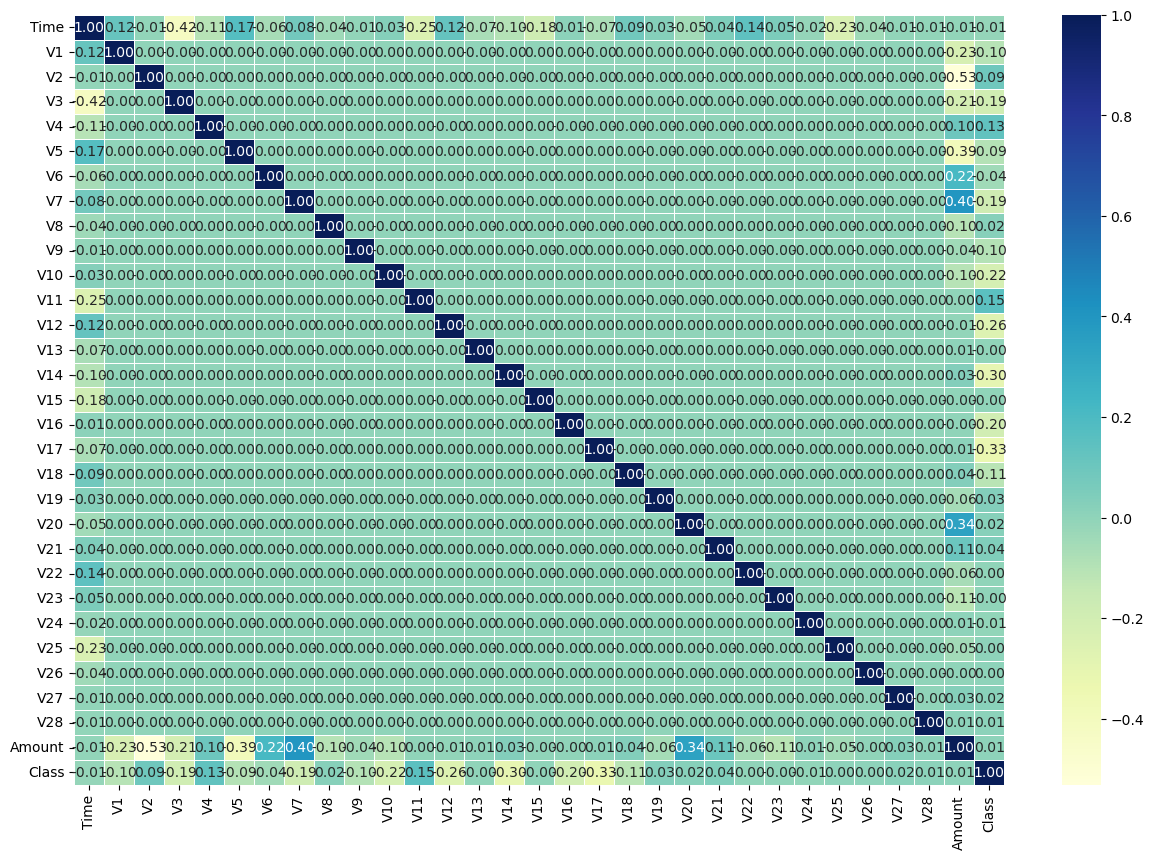

In [28]:
corr_matrix = df.corr()
fig, ax = plt.subplots(figsize= (15,10))
ax = sns.heatmap(corr_matrix
                 ,annot = True,
                 linewidths = 0.5,
                 fmt = ".2f",
                 cmap = "YlGnBu");

# Data Modelling
 We are going to use three models in this section:
 
- K-nearest Neighbour Classifier
- Random Forest Classifier
- Logistic Regression

In [13]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


### Splitting Data into train and test set

In [17]:
# Splitting data into X and y
X = df.drop("Class", axis = 1)
y = df["Class"]

# Random seed
np.random.seed(42)

# Train Test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2)

### Scaling the data

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### K-nearest Neighbour Classifier

In [19]:
# Random seed
np.random.seed(42)

# Initializing the model
clf1 = KNeighborsClassifier()

# Fitting the model
clf1.fit(X_train_scaled, y_train)

# Model score
Kneighbourscore = clf1.score(X_test_scaled,y_test)
Kneighbourscore

0.9995259997893332

### Random Forest 

In [20]:
# Initializing the model
clf2 = RandomForestClassifier(random_state= 42)

# Fitting the model
clf2.fit(X_train_scaled, y_train)

# Model score
RandomForestscore = clf2.score(X_test_scaled,y_test)
RandomForestscore

0.9995611109160493

### Logistic Regression

In [22]:
# Initializing the model
clf3 = LogisticRegression(random_state= 42)

# Fitting the model
clf3.fit(X_train_scaled, y_train)

# Model score
LogisticRegressionscore = clf3.score(X_test_scaled,y_test)
LogisticRegressionscore

0.9990695551420246

### Comparing the models

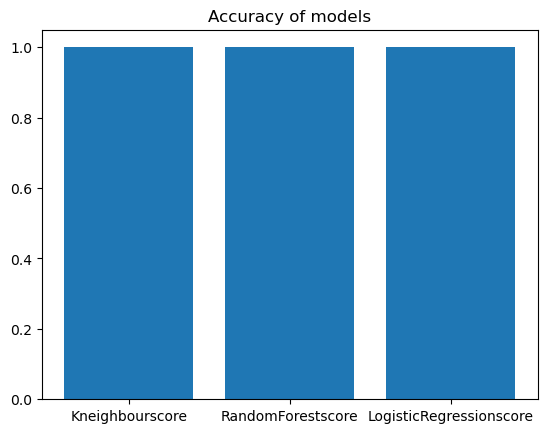

In [27]:
model = ["Kneighbourscore", "RandomForestscore", "LogisticRegressionscore"]
model_scores = [Kneighbourscore, RandomForestscore, LogisticRegressionscore]

plt.bar(model,model_scores)
plt.title("Accuracy of models")
plt.show();

 While it is very close, the best model is Random Forest Classifier

# Evaluation

### Predicting with our model

In [29]:
y_pred = clf2.predict(X_test_scaled)

In [33]:
## Classification Report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.77      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962



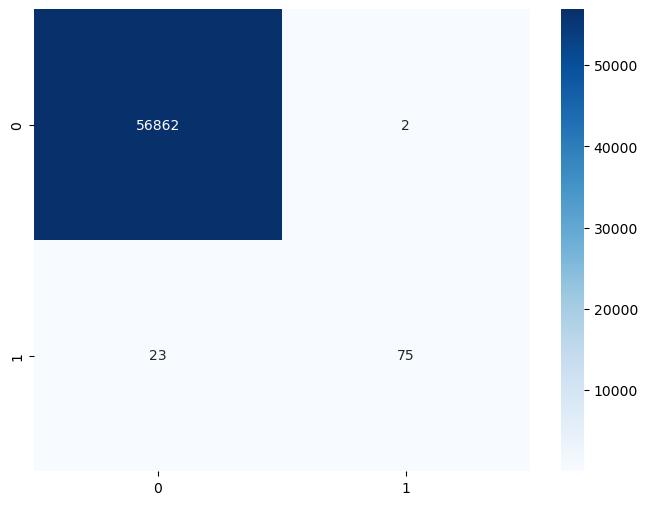

In [36]:
plt.figure(figsize= (8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, fmt = "d", annot = True, cmap = "Blues")
plt.title("Confusion Matrix")
plt.xlabel("True Label")
plt.ylabel("Predicted Label")
plt.show();

 As said in the beginning, given the class imbalance ratio, Area Under the Precision-Recall Curve (AUPRC) will be used for evaluation as confusion matrix accuracy is not meaningful for unbalanced classification.

### Area Under the Precision-Recall Curve (AUPRC) 

In [45]:
precision, recall, _ = precision_recall_curve(y_test, y_pred)
auc_pr = auc(recall, precision)
average_precision = average_precision_score(y_test, y_pred)
auc_pr

np.float64(0.8698679372160941)

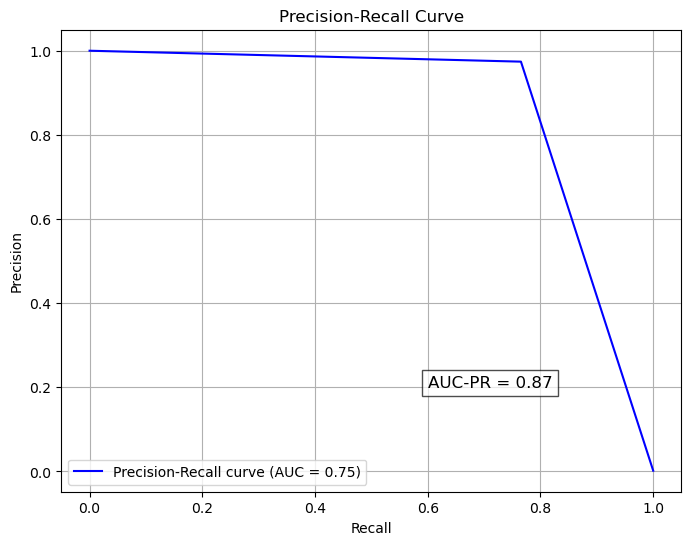

In [48]:
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall curve (AUC = {average_precision:.2f})', color='blue')
plt.text(x=0.6, y=0.2,s=f'AUC-PR = {auc_pr:.2f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid()
plt.show();

### Feature Importance

In [52]:
importance = clf2.feature_importances_
feature_imp = pd.DataFrame({
    "Features": X.columns,
    "Importance": importance
}).sort_values("Importance", ascending= False)

In [54]:
feature_imp.head(5)

,Features,Importance
17,V17,0.157500
12,V12,0.134876
14,V14,0.124647
10,V10,0.081051
16,V16,0.074765


This shows the features used for the creation of this model in order of it's importance.

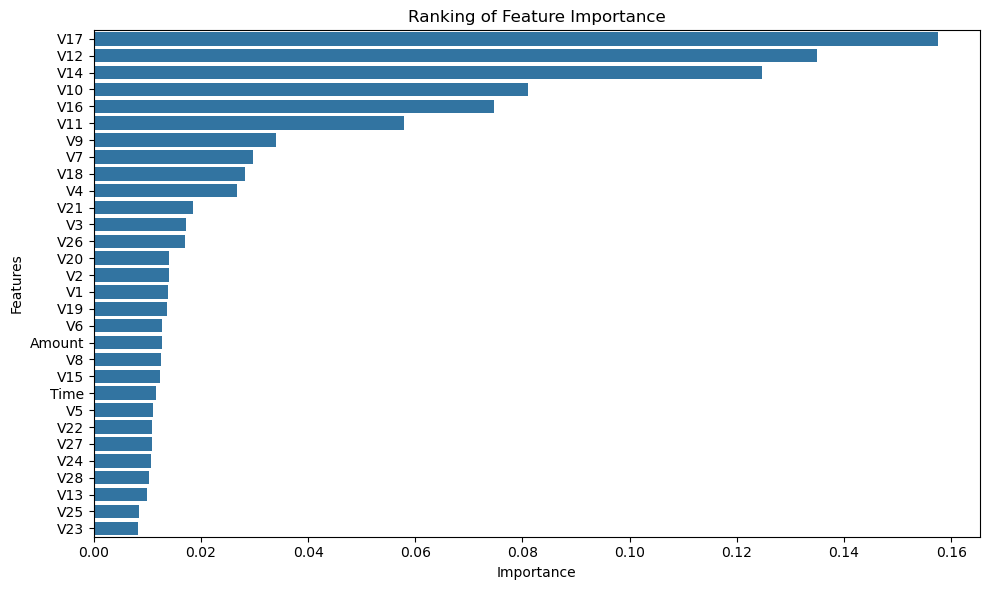

In [59]:
# Visualization
plt.figure(figsize = (10,6))
sns.barplot(data= feature_imp, x = "Importance", y = "Features")
plt.title("Ranking of Feature Importance")
plt.tight_layout()
plt.show();